# Setup Instructions

1. Mount Google Drive.
2. Download the Fashionpedia dataset.
3. Upload `val_test2020.zip` to your Google Drive.
4. Update `ZIP_PATH` if necessary.If not then upload the zip file in notebook and theres a code for it to unzip present in this notebook
5. its available in displayed retrieving images
6. Run all cells sequentially.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/fashion-retrieval"

os.chdir(PROJECT_ROOT)

print(os.getcwd())

/content/drive/MyDrive/fashion-retrieval


In [13]:
print(os.listdir("index_store"))

['metadata.json', 'faiss.index', 'fashionclip_embeddings.npy']


In [14]:
from pathlib import Path

retriever_dir = Path("retriever")
retriever_dir.mkdir(exist_ok=True)

(retriever_dir / "__init__.py").touch(exist_ok=True)

print("Retriever package ready.")

Retriever package ready.


Query

In [15]:
import importlib
import retriever.query

importlib.reload(retriever.query)

from retriever.query import QueryEncoder
from config import FASHIONCLIP_MODEL_PATH, DEVICE

encoder = QueryEncoder(
    model_path=str(FASHIONCLIP_MODEL_PATH),
    device=DEVICE
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [18]:
import torch

In [19]:
embedding = encoder.encode_text("blue denim jacket for women")

print(type(embedding))
print(embedding.shape)
print(torch.norm(embedding))

<class 'torch.Tensor'>
torch.Size([512])
tensor(1.0000)


Hybrid Search

In [20]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 107.3 MB/s eta 0:00:00


In [21]:
from retriever.hybrid_search import HybridSearcher

from config import (
    FAISS_INDEX_PATH,
    METADATA_PATH
)

searcher = HybridSearcher(
    index_path=FAISS_INDEX_PATH,
    metadata_path=METADATA_PATH
)

In [22]:
print("Number of vectors:", searcher.index.ntotal)

Number of vectors: 800


In [23]:
print("Metadata entries:", len(searcher.metadata))

Metadata entries: 800


In [24]:
query = "blue denim jacket for women"

query_embedding = encoder.encode_text(query)

In [25]:
results = searcher.search(
    query_embedding=query_embedding,
    top_k=10
)

In [26]:
print(type(results))
print(len(results))

<class 'list'>
10


In [27]:
from pprint import pprint

pprint(results[0])

{'caption': 'a woman in a denim jacket and ripped jeans',
 'embedding_index': 625,
 'garments': [{'color': None, 'type': 'jacket'},
              {'color': None, 'type': 'jeans'}],
 'image_id': 625,
 'image_name': 'aaa6cb392f709ada1eadcc4c146851a1.jpg',
 'image_path': '/content/fashionpedia/test/aaa6cb392f709ada1eadcc4c146851a1.jpg',
 'people': ['woman'],
 'scene': {'confidence': 0.16,
           'normalized': 'runway',
           'raw': 'stage/outdoor',
           'source': 'places365'},
 'tags': ['jacket', 'jeans', 'runway', 'woman'],
 'vector_score': 0.3271249532699585}


Semantic Parser

In [28]:
import importlib

import retriever.query
import retriever.hybrid_search
import retriever.semantic_parser

importlib.reload(retriever.query)
importlib.reload(retriever.hybrid_search)
importlib.reload(retriever.semantic_parser)

<module 'retriever.semantic_parser' from '/content/drive/MyDrive/fashion-retrieval/retriever/semantic_parser.py'>

In [29]:
import importlib
import retriever.semantic_parser

importlib.reload(retriever.semantic_parser)

from retriever.semantic_parser import SemanticParser

In [30]:
parser = SemanticParser()

In [31]:
import inspect

print(inspect.getsource(parser.parse))

    def parse(self, query: str) -> Dict:

        if not isinstance(query, str):
            raise TypeError("Query must be a string.")

        tokens = self._tokenize(query)

        colors = sorted(
            {
                token
                for token in tokens
                if token in self.COLORS
            }
        )

        garments = sorted(
            {
                token
                for token in tokens
                if token in self.GARMENTS
            }
        )

        people = sorted(
            {
                token
                for token in tokens
                if token in self.PEOPLE
            }
        )

        styles = sorted(
            {
                token
                for token in tokens
                if token in self.STYLES
            }
        )

        scenes = sorted(
            {
                token
                for token in tokens
                if token in self.SCENES
            }
        )

        s

In [32]:
from pprint import pprint

pprint(
    parser.parse(
        "black hoodie for men in park"
    )
)

{'colors': ['black'],
 'garments': ['hoodie'],
 'people': ['man'],
 'scene': 'park',
 'styles': [],
 'tokens': ['black', 'hoodie', 'man', 'park']}


Reranker

In [33]:
import importlib
import retriever.reranker

importlib.reload(retriever.reranker)

from retriever.reranker import HybridReranker

In [34]:
reranker = HybridReranker()

In [35]:
query = "blue denim jacket for women"

# Step 1
parsed_query = parser.parse(query)

# Step 2
query_embedding = encoder.encode_text(query)

# Step 3
candidates = searcher.search(
    query_embedding,
    top_k=50
)

# Step 4
results = reranker.rerank(
    parsed_query,
    candidates
)

In [36]:
print(results[0].keys())

dict_keys(['image_id', 'image_name', 'image_path', 'embedding_index', 'caption', 'scene', 'people', 'garments', 'tags', 'vector_score', 'garment_score', 'style_score', 'people_score', 'scene_score', 'tag_score', 'final_score'])


In [37]:
print(len(results))

50


In [38]:
for rank, result in enumerate(results[:10], start=1):

    print("=" * 90)

    print(f"Rank            : {rank}")

    print(f"Image           : {result['image_name']}")

    print(f"Caption         : {result['caption']}")

    print()

    print(f"Vector Score    : {result['vector_score']:.4f}")
    print(f"Garment Score   : {result['garment_score']:.4f}")
    print(f"Style Score     : {result['style_score']:.4f}")
    print(f"People Score    : {result['people_score']:.4f}")
    print(f"Scene Score     : {result['scene_score']:.4f}")
    print(f"Tag Score       : {result['tag_score']:.4f}")

    print("-" * 45)

    print(f"Final Score     : {result['final_score']:.4f}")

    print()

    print(f"People          : {result['people']}")
    print(f"Scene           : {result['scene']['normalized']}")
    print(f"Tags            : {', '.join(result['tags'])}")

Rank            : 1
Image           : aaa6cb392f709ada1eadcc4c146851a1.jpg
Caption         : a woman in a denim jacket and ripped jeans

Vector Score    : 0.3271
Garment Score   : 1.0000
Style Score     : 1.0000
People Score    : 1.0000
Scene Score     : 0.0000
Tag Score       : 0.7500
---------------------------------------------
Final Score     : 0.6681

People          : ['woman']
Scene           : runway
Tags            : jacket, jeans, runway, woman
Rank            : 2
Image           : 906bc8a73ba1d28c2ae3793b54f57d20.jpg
Caption         : a woman in jeans and a denim jacket drinking coffee

Vector Score    : 0.3046
Garment Score   : 1.0000
Style Score     : 1.0000
People Score    : 1.0000
Scene Score     : 0.0000
Tag Score       : 0.7500
---------------------------------------------
Final Score     : 0.6574

People          : ['woman']
Scene           : other
Tags            : jacket, jeans, other, woman
Rank            : 3
Image           : 112a9c9b9c7a97f3f632b2ec7fd064e5.jpg


In [39]:
from pprint import pprint

pprint(results[0])

{'caption': 'a woman in a denim jacket and ripped jeans',
 'embedding_index': 625,
 'final_score': 0.6681118199699803,
 'garment_score': 1.0,
 'garments': [{'color': None, 'type': 'jacket'},
              {'color': None, 'type': 'jeans'}],
 'image_id': 625,
 'image_name': 'aaa6cb392f709ada1eadcc4c146851a1.jpg',
 'image_path': '/content/fashionpedia/test/aaa6cb392f709ada1eadcc4c146851a1.jpg',
 'people': ['woman'],
 'people_score': 1.0,
 'scene': {'confidence': 0.16,
           'normalized': 'runway',
           'raw': 'stage/outdoor',
           'source': 'places365'},
 'scene_score': 0.0,
 'style_score': 1.0,
 'tag_score': 0.75,
 'tags': ['jacket', 'jeans', 'runway', 'woman'],
 'vector_score': 0.3271249532699585}


TESTING

In [56]:
#query ecoder
query = "blue denim jacket for women"

embedding = encoder.encode_text(query)

print("Shape :", embedding.shape)
print("Norm  :", embedding.norm())

Shape : torch.Size([512])
Norm  : tensor(1.0000)


In [57]:
#semantic parser
query = "blue denim jacket for women in park"

parsed = parser.parse(query)

from pprint import pprint
pprint(parsed)

{'colors': ['blue'],
 'garments': ['jacket'],
 'people': ['woman'],
 'scene': 'park',
 'styles': ['denim'],
 'tokens': ['blue', 'denim', 'jacket', 'park', 'woman']}


In [58]:
#faiss
query = "blue denim jacket for women"

query_embedding = encoder.encode_text(query)

baseline = searcher.search(
    query_embedding=query_embedding,
    top_k=5
)

for item in baseline:
    print(item["caption"])

a woman in a denim jacket and ripped jeans
a woman walking down the street in a black jacket
a woman in jeans and a denim jacket drinking coffee
a young woman leaning against a wall
a woman in a denim jacket and skirt walking down the street


In [59]:
#hybrid
parsed_query = parser.parse(query)

results = reranker.rerank(
    parsed_query,
    baseline
)

In [60]:
for r in results[:5]:

    print("="*80)

    print(r["caption"])

    print("Vector :", round(r["vector_score"],3))

    print("Final  :", round(r["final_score"],3))

    print("Garment:", r["garment_score"])

    print("Style  :", r["style_score"])

    print("People :", r["people_score"])

    print("Scene  :", r["scene_score"])

    print("Tags   :", r["tag_score"])

a woman in a denim jacket and ripped jeans
Vector : 0.327
Final  : 0.668
Garment: 1.0
Style  : 1.0
People : 1.0
Scene  : 0.0
Tags   : 0.75
a woman in jeans and a denim jacket drinking coffee
Vector : 0.305
Final  : 0.657
Garment: 1.0
Style  : 1.0
People : 1.0
Scene  : 0.0
Tags   : 0.75
a woman in a denim jacket and skirt walking down the street
Vector : 0.301
Final  : 0.656
Garment: 1.0
Style  : 1.0
People : 1.0
Scene  : 0.0
Tags   : 0.75
a woman walking down the street in a black jacket
Vector : 0.308
Final  : 0.488
Garment: 1.0
Style  : 0.0
People : 1.0
Scene  : 0.0
Tags   : 0.5
a young woman leaning against a wall
Vector : 0.304
Final  : 0.262
Garment: 0.0
Style  : 0.0
People : 1.0
Scene  : 0.0
Tags   : 0.25


In [61]:
#before vs after
query = "black leather jacket for woman"

parsed = parser.parse(query)

embedding = encoder.encode_text(query)

baseline = searcher.search(
    embedding,
    top_k=10
)

reranked = reranker.rerank(
    parsed,
    baseline
)

print("BASELINE")
print("-"*50)

for x in baseline[:5]:
    print(x["caption"])

print("\nHYBRID")
print("-"*50)

for x in reranked[:5]:
    print(x["caption"])

BASELINE
--------------------------------------------------
a model walks the runway at the person show
person in a black fur coat and leather pants
a woman in white pants and a black leather jacket walking down the runway
a woman in a black leather jacket and jeans is walking down a path
a model walks the runway at the person show

HYBRID
--------------------------------------------------
a woman in white pants and a black leather jacket walking down the runway
a woman in a black leather jacket and jeans is walking down a path
a woman in a denim jacket and skirt walking down the street
a woman in a black top and black shorts
person in a black fur coat and leather pants


FINAL TESTING AFTER ORCHEASTRATING

In [62]:
from retriever.retrieval_system import FashionRetrievalSystem

In [63]:
system = FashionRetrievalSystem(
    query_encoder=encoder,
    semantic_parser=parser,
    hybrid_searcher=searcher,
    reranker=reranker
)

In [64]:
results = system.search(
    query="blue denim jacket for women",
    top_k=5
)

In [65]:
for i, result in enumerate(results, start=1):

    print("=" * 90)

    print(f"Rank          : {i}")
    print(f"Image         : {result['image_name']}")
    print(f"Caption       : {result['caption']}")

    print()

    print(f"Vector Score  : {result['vector_score']:.4f}")
    print(f"Final Score   : {result['final_score']:.4f}")

    print()

    print(f"People        : {result['people']}")
    print(f"Scene         : {result['scene']['normalized']}")
    print(f"Tags          : {', '.join(result['tags'])}")

Rank          : 1
Image         : aaa6cb392f709ada1eadcc4c146851a1.jpg
Caption       : a woman in a denim jacket and ripped jeans

Vector Score  : 0.3271
Final Score   : 0.6681

People        : ['woman']
Scene         : runway
Tags          : jacket, jeans, runway, woman
Rank          : 2
Image         : 906bc8a73ba1d28c2ae3793b54f57d20.jpg
Caption       : a woman in jeans and a denim jacket drinking coffee

Vector Score  : 0.3046
Final Score   : 0.6574

People        : ['woman']
Scene         : other
Tags          : jacket, jeans, other, woman
Rank          : 3
Image         : 112a9c9b9c7a97f3f632b2ec7fd064e5.jpg
Caption       : a woman in a denim jacket and skirt walking down the street

Vector Score  : 0.3007
Final Score   : 0.6556

People        : ['woman']
Scene         : street
Tags          : jacket, skirt, street, woman
Rank          : 4
Image         : 14ce620645bc27f4710e2141432e7139.jpg
Caption       : a woman walking down the street in a black jacket

Vector Score  : 0.3078

In [66]:
output = system.explain(
    "blue denim jacket for women"
)

In [67]:
#explanation
from pprint import pprint

print("Parsed Query")
print("-" * 40)

pprint(output["parsed_query"])

Parsed Query
----------------------------------------
{'colors': ['blue'],
 'garments': ['jacket'],
 'people': ['woman'],
 'scene': None,
 'styles': ['denim'],
 'tokens': ['blue', 'denim', 'jacket', 'woman']}


Display Retrieved Images

In [68]:
!cp "/content/drive/MyDrive/fashion-retrieval/val_test2020.zip" /content/

In [69]:
import os

print(os.path.exists("/content/val_test2020.zip"))
print(os.path.getsize("/content/val_test2020.zip") / (1024*1024), "MB")

True
225.54305458068848 MB


In [70]:
from zipfile import ZipFile
from pathlib import Path

ZIP_PATH = "/content/val_test2020.zip"
EXTRACT_PATH = "/content/fashionpedia"

Path(EXTRACT_PATH).mkdir(parents=True, exist_ok=True)

with ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extraction Complete!")

Extraction Complete!


In [71]:
from pathlib import Path

jpgs = list(Path("/content/fashionpedia").rglob("*.jpg"))

print("Total images:", len(jpgs))
print(jpgs[:5])

Total images: 3200
[PosixPath('/content/fashionpedia/test/f57152e44f9348050d59a71f9ca7f220.jpg'), PosixPath('/content/fashionpedia/test/9cad0d1244d0d99582490e482226078d.jpg'), PosixPath('/content/fashionpedia/test/2f103ab523c1808e842eead692ec5c40.jpg'), PosixPath('/content/fashionpedia/test/2faebabe4dc2c4fd180e5066d7a89282.jpg'), PosixPath('/content/fashionpedia/test/712958df9c9b2c62f9a18f82388a34be.jpg')]


In [72]:
from pathlib import Path

image_name = results[0]["image_name"]

matches = list(Path("/content/fashionpedia").rglob(image_name))

print(matches)

[PosixPath('/content/fashionpedia/test/aaa6cb392f709ada1eadcc4c146851a1.jpg')]


In [73]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

DATASET_ROOT = Path("/content/fashionpedia/test")

def show_results(results):

    top_k = len(results)

    cols = 2
    rows = (top_k + cols - 1) // cols

    plt.figure(figsize=(14, rows * 6))

    for i, result in enumerate(results):

        image_path = DATASET_ROOT / result["image_name"]

        if not image_path.exists():
            print(f"Missing image: {image_path}")
            continue

        image = Image.open(image_path).convert("RGB")

        plt.subplot(rows, cols, i + 1)

        plt.imshow(image)
        plt.axis("off")

        plt.title(
            f"Rank {i+1}\n"
            f"Score: {result['final_score']:.3f}\n\n"
            f"{result['caption']}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

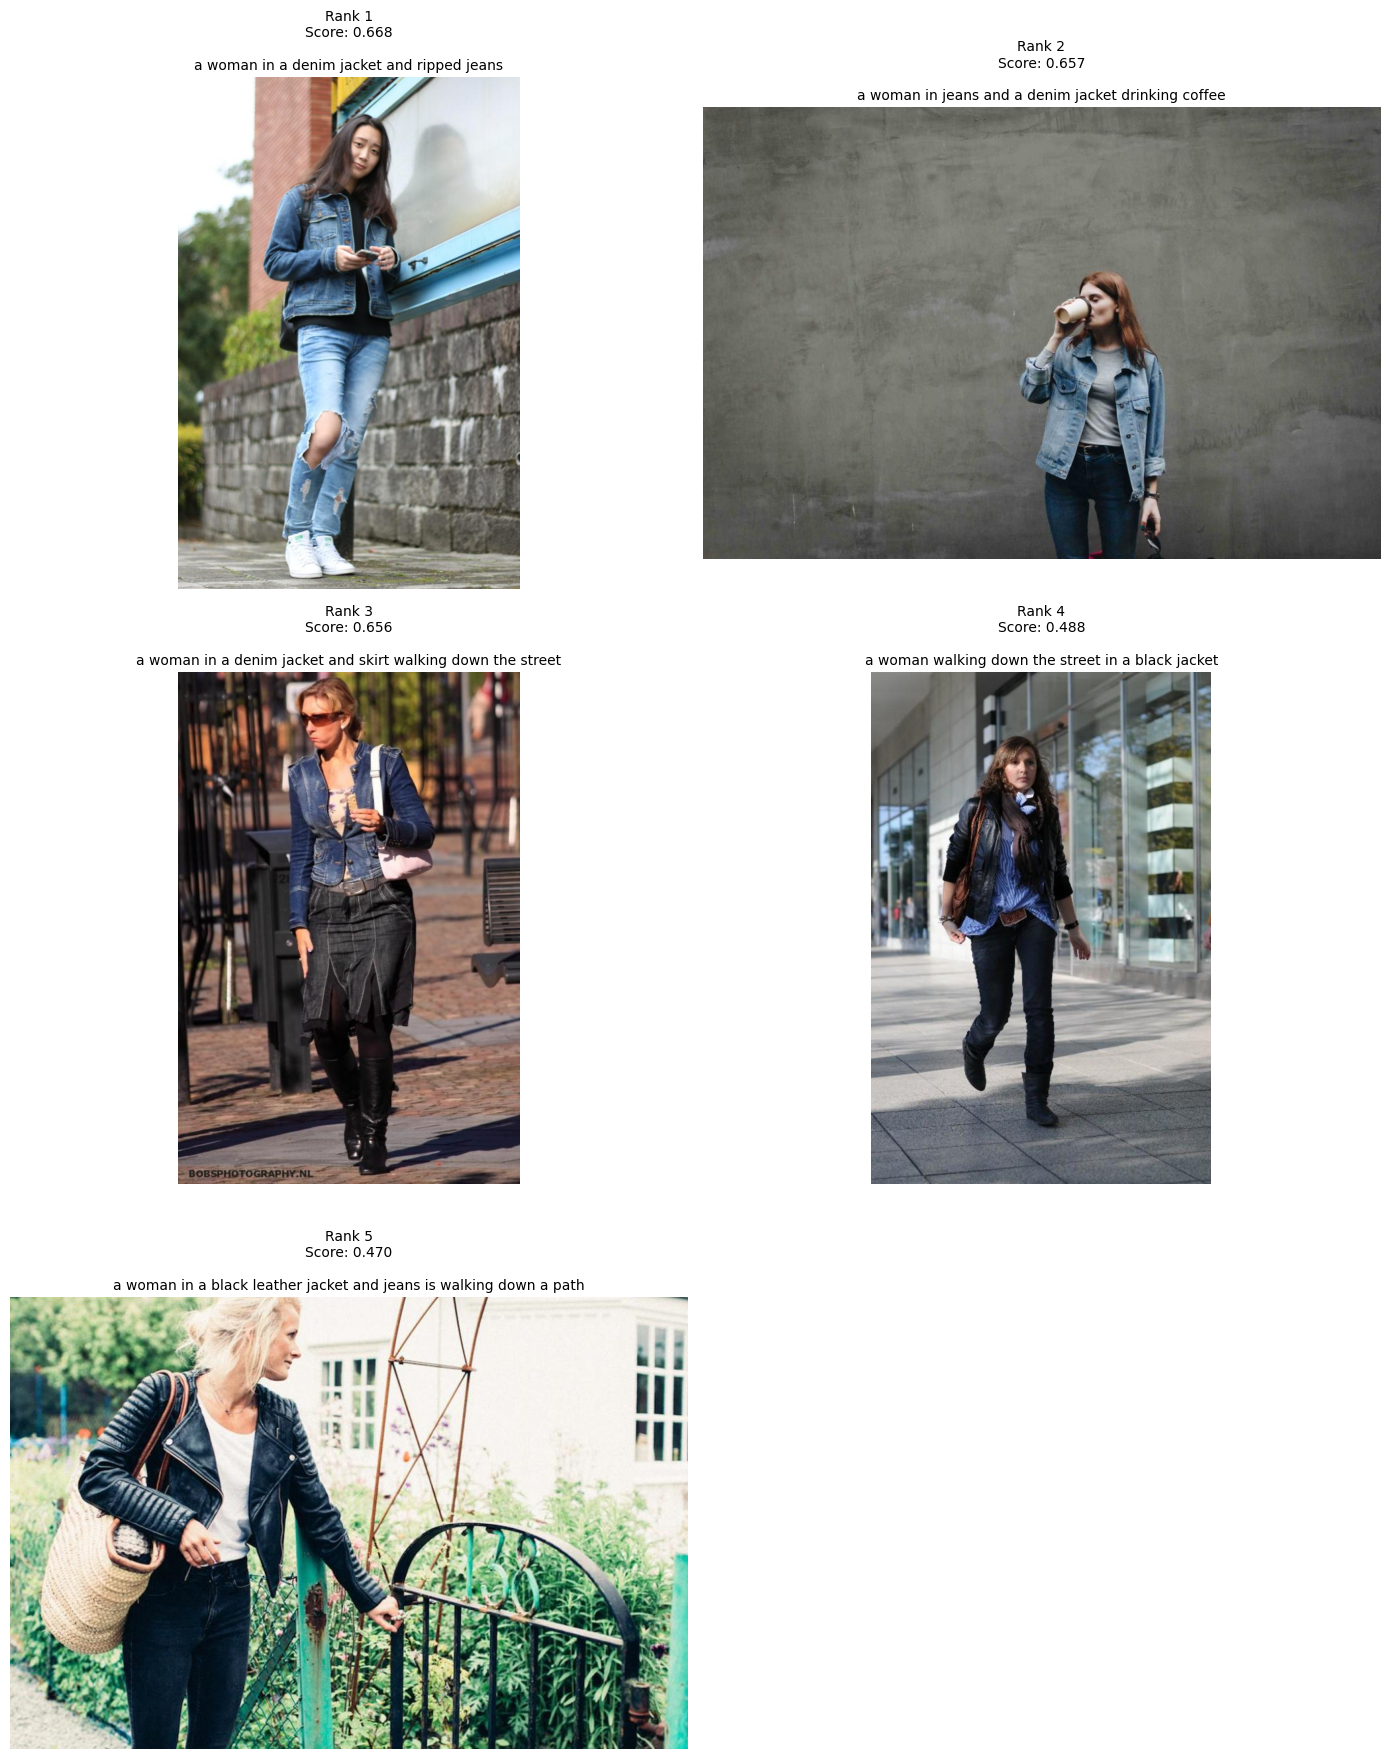

In [74]:
query = "blue denim jacket for women"

results = system.search(
    query=query,
    top_k=5
)

show_results(results)

EVALUATION


In [75]:
from evaluation.metrics import RetrievalMetrics

metrics = RetrievalMetrics()

metrics.update(results)

metrics.print_summary()

Evaluation Summary
Average Vector Score          : 0.3019
Average Final Score           : 0.5878
Average Garment Score         : 1.0000
Average Style Score           : 0.6000
Average People Score          : 1.0000
Average Scene Score           : 0.0000
Average Tag Score             : 0.6500
Queries Evaluated             : 5


In [76]:
from evaluation.evaluate import evaluate

In [77]:
evaluate(
    retrieval_system=system,
    top_k=5
)

Running Evaluation

Query : blue denim jacket for women
--------------------------------------------------------------------------------
1. a woman in a denim jacket and ripped jeans (Score: 0.6681)
2. a woman in jeans and a denim jacket drinking coffee (Score: 0.6574)
3. a woman in a denim jacket and skirt walking down the street (Score: 0.6556)
4. a woman walking down the street in a black jacket (Score: 0.4879)
5. a woman in a black leather jacket and jeans is walking down a path (Score: 0.4697)

Query : black leather jacket
--------------------------------------------------------------------------------
1. a woman in white pants and a black leather jacket walking down the runway (Score: 0.5384)
2. a man in a black leather jacket and jeans walks down the runway (Score: 0.5319)
3. a woman in a black leather jacket and jeans is walking down a path (Score: 0.5283)
4. a woman in a white skirt and black jacket (Score: 0.5279)
5. a man in a black jacket and jeans walks down the runway (Sc

[{'query': 'blue denim jacket for women',
  'results': [{'rank': 1,
    'image_name': 'aaa6cb392f709ada1eadcc4c146851a1.jpg',
    'caption': 'a woman in a denim jacket and ripped jeans',
    'vector_score': 0.3271249532699585,
    'final_score': 0.6681118199699803,
    'garment_score': 1.0,
    'style_score': 1.0,
    'people_score': 1.0,
    'scene_score': 0.0,
    'tag_score': 0.75},
   {'rank': 2,
    'image_name': '906bc8a73ba1d28c2ae3793b54f57d20.jpg',
    'caption': 'a woman in jeans and a denim jacket drinking coffee',
    'vector_score': 0.30460530519485474,
    'final_score': 0.6574446182501943,
    'garment_score': 1.0,
    'style_score': 1.0,
    'people_score': 1.0,
    'scene_score': 0.0,
    'tag_score': 0.75},
   {'rank': 3,
    'image_name': '112a9c9b9c7a97f3f632b2ec7fd064e5.jpg',
    'caption': 'a woman in a denim jacket and skirt walking down the street',
    'vector_score': 0.30074191093444824,
    'final_score': 0.6556145893900017,
    'garment_score': 1.0,
    'sty